In [1]:
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
import sys
print(sys.executable)

import os
os.getcwd()

import gc

/apps/leuven/rocky8/skylake/2021a/software/Python/3.9.5-GCCcore-10.3.0/bin/python


In [3]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.append('/user/leuven/384/vsc38419/0scillons/February26Oscillons/Feb26')

from core.grid import Grid
from core.rhsevolution_MG import *
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter_MG import *

from bssn.oscillondiagnostic import (get_oscillon_diagnostic,
                                     plot_density_profiles_at_times,
                                     plot_paper_diagnostics)

from initialdata.ModifiedGravityInitialConditions import *

from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *

In [4]:
####################################################
# SWEEP PARAMETERS — lists of values to loop over
# (itertools.product handles unequal lengths)
####################################################

amplitudes   = [-2e-2]                  # perturbation amplitude
widths_R     = [3]                      # perturbation width / R
lambda_GBs   = [0.01]              # GB coupling constant
mus          = [0.08]                   # self-interaction (key into TABLE_I)

####################################################
# FIXED PARAMETERS
####################################################

scalar_mu = 1
a = 0.2
b = 0.4
chi0 = 0.15
coupling = 'quadratic'

TABLE_I = {
    0.04: dict(phi=-6.03334e-2, dphi=2.20256e-2, H=1.55744e-2),
    0.05: dict(phi=-7.36454e-2, dphi=2.72499e-2, H=1.92686e-2),
    0.06: dict(phi=-8.64102e-2, dphi=3.23761e-2, H=2.28934e-2),
    0.07: dict(phi=-9.86792e-2, dphi=3.74094e-2, H=2.64525e-2),
    0.08: dict(phi=-1.10495e-1, dphi=4.23540e-2, H=2.99488e-2),
    0.09: dict(phi=-1.21893e-1, dphi=4.72136e-2, H=3.33851e-2),
    0.10: dict(phi=-1.32906e-1, dphi=5.19917e-2, H=3.67637e-2),
}

# Time
T = 800
num_points_t = 1000
dt = T / num_points_t
t = np.linspace(0, T - dt, num_points_t)

In [5]:
####################################################
# RESOLUTION & GRID SETTINGS
####################################################

r_max = 150
min_dr = 1 / 4          # single resolution for the sweep
max_dr = 2

resolutions = {
    'LR': 1 / 4,
    'MR': 1 / 8,
    'HR': 1 / 16,
}

# Set to ['LR'] for quick sweeps, or ['LR','MR','HR'] for convergence
active_resolutions = ['HR']

print(f"Active resolutions: {active_resolutions}")
for tag, dr in resolutions.items():
    if tag in active_resolutions:
        print(f"  {tag}: min_dr = {dr}")

Active resolutions: ['HR']
  HR: min_dr = 0.0625


In [6]:
####################################################
# DATA DIRECTORY — one subfolder per parameter set
####################################################
import itertools

NOTEBOOK_DIR = "/user/leuven/384/vsc38419/0scillons/February26Oscillons/Feb26/Notebooks"
BASE_DIR = os.path.join(NOTEBOOK_DIR, "oscillon_MG")

def make_run_dir(lgb, mu, a_param, b_param, amp, R, dr):
    """Build a unique subfolder name encoding every physics + grid parameter."""
    tag = (f"lgb{lgb}_mu{mu}_a{a_param}_b{b_param}"
           f"_amp{amp}_R{R}_dr{dr}")
    run_dir = os.path.join(BASE_DIR, tag)
    os.makedirs(run_dir, exist_ok=True)
    return run_dir

combos = list(itertools.product(amplitudes, widths_R, lambda_GBs, mus))
n_runs = len(combos) * len(active_resolutions)
print(f"{len(combos)} parameter combinations x {len(active_resolutions)} resolutions = {n_runs} total runs")
for i, (amp, wR, lgb, mu) in enumerate(combos):
    print(f"  [{i}] amp={amp}, R={wR}, lgb={lgb}, mu={mu}")

1 parameter combinations x 1 resolutions = 1 total runs
  [0] amp=-0.02, R=3, lgb=0.01, mu=0.08


# Simulation Loop

In [11]:
####################################################
# MAIN SIMULATION LOOP
####################################################

run_counter = 0

for amp, wR, lgb, mu in combos:

    u_val = TABLE_I[mu]['phi']
    v_val = TABLE_I[mu]['dphi']

    my_matter = ScalarMatter(scalar_mu, mu)
    my_state_vector = StateVector(my_matter)

    for res_tag in active_resolutions:
        run_counter += 1
        min_dr_cur = resolutions[res_tag]

        spacing_cur = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr_cur, max_dr))
        grid_cur = Grid(spacing_cur, my_state_vector)
        r_cur = grid_cur.r
        background_cur = FlatSphericalBackground(r_cur)

        run_dir = make_run_dir(lgb, mu, a, b, amp, wR, min_dr_cur)

        print(f"\n{'='*60}")
        print(f"Run {run_counter}/{n_runs}  [{res_tag}]")
        print(f"  lgb={lgb}, mu={mu}, a={a}, b={b}, amp={amp}, R={wR}, dr={min_dr_cur}")
        print(f"  Grid: {r_cur.size} points  ->  {run_dir}")

        initial_state = get_initial_state(
            grid_cur, background_cur, (lgb, a, b, chi0, coupling),
            my_matter, amp, wR, scalar_mu, u_val, v_val)

        with tqdm(total=1000, unit="\u2030") as progress_bar:
            dense_sol = solve_ivp(
                get_rhs, [0, T], initial_state,
                args=(grid_cur, background_cur, my_matter, progress_bar,
                      [0, T/1000], a, b, lgb, coupling),
                max_step=0.4 * min_dr_cur,
                method='RK45',
                dense_output=True)

        solution = dense_sol.sol(t).T

        np.save(os.path.join(run_dir, "solution.npy"), solution)
        np.save(os.path.join(run_dir, "t.npy"), t)
        np.save(os.path.join(run_dir, "r.npy"), r_cur)
        print(f"  Saved: shape {solution.shape}")

        del dense_sol, solution, initial_state
        gc.collect()

print(f"\nAll {run_counter} runs complete.")


Run 1/1  [HR]
  lgb=0.01, mu=0.08, a=0.2, b=0.4, amp=-0.02, R=3, dr=0.0625
  Grid: 216 points  ->  /user/leuven/384/vsc38419/0scillons/February26Oscillons/Feb26/Notebooks/oscillon_MG/lgb0.01_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625
error is:  0.00975394413816646  after iter:  14


  0%|          | 0/1000 [00:00<?, ?‰/s]

KeyboardInterrupt: 

In [9]:
my_matter = ScalarMatter(scalar_mu, mu)
my_state_vector = StateVector(my_matter)

spacing_cur = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr_cur, max_dr))
grid_cur = Grid(spacing_cur, my_state_vector)
r_cur = grid_cur.r
background_cur = FlatSphericalBackground(r_cur)


DATA_DIR = os.path.join(NOTEBOOK_DIR, "convergence_data")
os.makedirs(DATA_DIR, exist_ok=True)

sol_HR = np.load(os.path.join(DATA_DIR, "solution_HR.npy"))
print(f"Loaded HR: {sol_HR.shape}")
osc_HR = get_oscillon_diagnostic(sol_HR, t, grid_cur, background_cur,
                                  my_matter, params_d, surface_threshold=0.05,
                                  r_max_diag=r_max_diag)
del sol_HR; gc.collect()

Loaded HR: (1000, 3024)


19

In [10]:
####################################################
# DIAGNOSTICS — load every saved run
####################################################

from bssn.oscillondiagnostic import (
    get_oscillon_diagnostic,
    plot_paper_diagnostics,
    plot_density_profiles_at_times,
    plot_density_contrast_profiles,
    plot_density_contrast_vs_lna,
    plot_central_density_vs_lna,
    plot_density_contrast_comparison,
    plot_hubble_vs_lna,
)

r_max_diag = 100.0
all_diagnostics = {}

for amp, wR, lgb, mu in combos:
    my_matter_diag = ScalarMatter(scalar_mu, mu)
    my_sv_diag = StateVector(my_matter_diag)

    for res_tag in active_resolutions:
        min_dr_cur = resolutions[res_tag]
        run_dir = make_run_dir(lgb, mu, a, b, amp, wR, min_dr_cur)

        sol = np.load(os.path.join(run_dir, "solution.npy"))
        t_loaded = np.load(os.path.join(run_dir, "t.npy"))

        spacing_d = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr_cur, max_dr))
        grid_d = Grid(spacing_d, my_sv_diag)
        bg_d = FlatSphericalBackground(grid_d.r)

        params_d = (lgb, a, b, chi0, coupling)
        label = f"lgb={lgb}, mu={mu}, amp={amp}, R={wR}, {res_tag}"
        print(f"Diagnosing: {label}  (shape {sol.shape})")

        osc = get_oscillon_diagnostic(sol, t_loaded, grid_d, bg_d,
                                       my_matter_diag, params_d,
                                       surface_threshold=0.05,
                                       r_max_diag=r_max_diag)

        key = (amp, wR, lgb, mu, res_tag)
        all_diagnostics[key] = dict(osc=osc, t=t_loaded, grid=grid_d,
                                    bg=bg_d, matter=my_matter_diag,
                                    params=params_d, label=label,
                                    run_dir=run_dir)

        del sol; gc.collect()

print(f"\nLoaded {len(all_diagnostics)} diagnostic sets.")
print("Keys stored per run:", list(list(all_diagnostics.values())[0]['osc'].keys()))

Diagnosing: lgb=0.01, mu=0.08, amp=-0.02, R=3, HR  (shape (1000, 3024))

Loaded 1 diagnostic sets.
Keys stored per run: ['t', 'r', 'rho', 'rho_c', 'rho_bar', 'delta_c', 'delta_rho', 'a', 'ln_a', 'K_avg', 'M', 'V_proper', 'R', 'C', 'u_c', 'u_bar', 'Asq_c']


/tmp/ipykernel_1296297/2987700368.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_bot.legend(fontsize=8, loc='upper right')


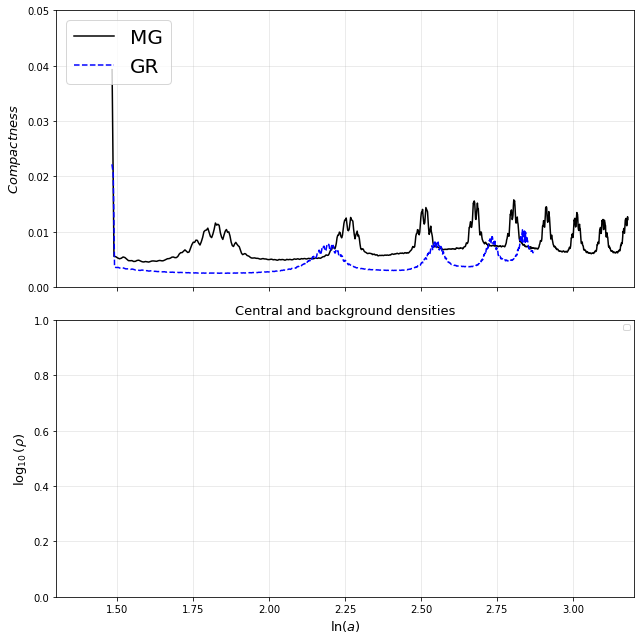

In [11]:
####################################################
# Paper-style: delta_c and rho_c vs ln(a) — all runs
####################################################

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

for key, entry in all_diagnostics.items():
    osc = entry['osc']
    lbl = entry['label']

    ln_a    = osc["ln_a"]
    delta_c = osc["delta_c"]
    rho_c   = osc["rho_c"]
    rho_bar = osc["rho_bar"]

    pos_dc = delta_c > 0
    log_dc = np.full_like(delta_c, np.nan)
    log_dc[pos_dc] = np.log10(delta_c[pos_dc])

    pos_rc = rho_c > 0
    log_rc = np.full_like(rho_c, np.nan)
    log_rc[pos_rc] = np.log10(rho_c[pos_rc])

    pos_rb = rho_bar > 0
    log_rb = np.full_like(rho_bar, np.nan)
    log_rb[pos_rb] = np.log10(rho_bar[pos_rb])
    
    ha= 111
    ho= 171
    
    ax_top.plot(ln_a[ha:], osc["C"][ha:], 'k-',lw=1.5 ,label="MG")

    # HERE I SHIFTED THE GR COMPACTNESS TO MATCH THEM IN TIME
    ax_top.plot(ln_a[ho:]-0.307, osc_HR["C"][ho:],'b--', lw=1.5, label="GR")
    ax_top.set_xlim(1.3, 3.2)
    ax_top.set_ylim(0,0.05)
    
    #ax_bot.plot(ln_a, log_rc, lw=1.5, label=rf'$\rho_c$ {lbl}')
    #ax_bot.plot(ln_a, log_rb, '--', lw=1.0, alpha=0.5, label=rf'$\bar{{\rho}}$ {lbl}')

ax_top.set_ylabel(r'$Compactness$', fontsize=13)
#ax_top.set_title(r'Density contrast  $\delta_c \equiv \rho_c/\bar\rho - 1$', fontsize=13)
ax_top.legend(fontsize=20, loc='upper left')
ax_top.grid(True, alpha=0.3)

ax_bot.set_xlabel(r'$\ln(a)$', fontsize=13)
ax_bot.set_ylabel(r'$\log_{10}(\rho)$', fontsize=13)
ax_bot.set_title(r'Central and background densities', fontsize=13)
ax_bot.legend(fontsize=8, loc='upper right')
ax_bot.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

/tmp/ipykernel_527629/2881230242.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_bot.legend(fontsize=8, loc='upper right')


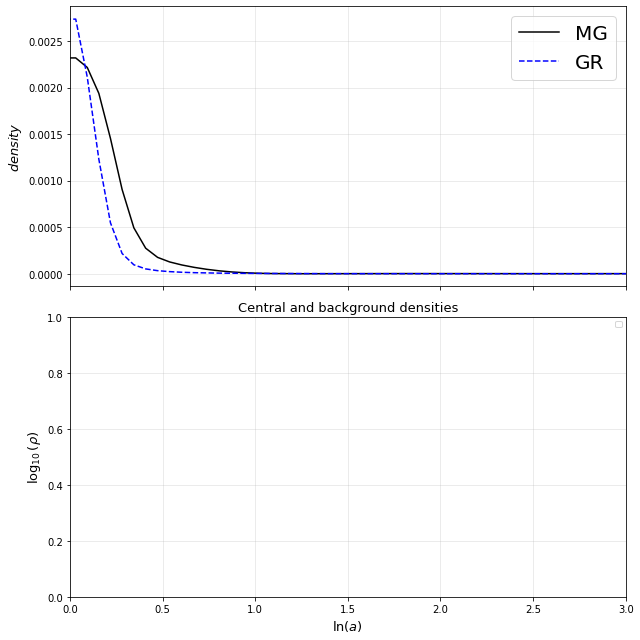

In [21]:
####################################################
# Paper-style: delta_c and rho_c vs ln(a) — all runs
####################################################

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

for key, entry in all_diagnostics.items():
    osc = entry['osc']
    lbl = entry['label']

    ln_a    = osc["ln_a"]
    delta_c = osc["delta_c"]
    rho_c   = osc["rho_c"]
    rho_bar = osc["rho_bar"]

    pos_dc = delta_c > 0
    log_dc = np.full_like(delta_c, np.nan)
    log_dc[pos_dc] = np.log10(delta_c[pos_dc])

    pos_rc = rho_c > 0
    log_rc = np.full_like(rho_c, np.nan)
    log_rc[pos_rc] = np.log10(rho_c[pos_rc])

    pos_rb = rho_bar > 0
    log_rb = np.full_like(rho_bar, np.nan)
    log_rb[pos_rb] = np.log10(rho_bar[pos_rb])

    ax_top.plot(osc['r'], osc["rho"][700], 'k-',lw=1.5 ,label="MG")

    ax_top.plot(osc['r'], osc_HR["rho"][700],'b--', lw=1.5, label="GR")
    ax_top.set_xlim(0, 3)
    
    #ax_bot.plot(ln_a, log_rc, lw=1.5, label=rf'$\rho_c$ {lbl}')
    #ax_bot.plot(ln_a, log_rb, '--', lw=1.0, alpha=0.5, label=rf'$\bar{{\rho}}$ {lbl}')

ax_top.set_ylabel(r'$density$', fontsize=13)
#ax_top.set_title(r'Density contrast  $\delta_c \equiv \rho_c/\bar\rho - 1$', fontsize=13)
ax_top.legend(fontsize=20, loc='upper right')
ax_top.grid(True, alpha=0.3)

ax_bot.set_xlabel(r'$\ln(a)$', fontsize=13)
ax_bot.set_ylabel(r'$\log_{10}(\rho)$', fontsize=13)
ax_bot.set_title(r'Central and background densities', fontsize=13)
ax_bot.legend(fontsize=8, loc='upper right')
ax_bot.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

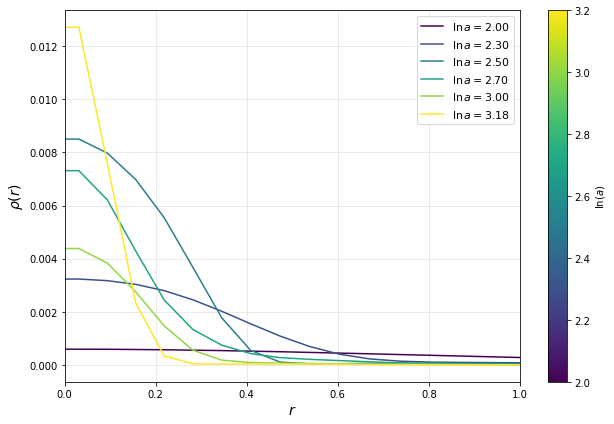

In [23]:
####################################################
# Radial density profile at chosen ln(a) values
####################################################
import matplotlib.cm as cm

lna_values =  [2.0,2.3 ,2.5,2.7, 3.0, 3.2]

for key, entry in all_diagnostics.items():
    osc = entry['osc']
    lbl = entry['label']
    r     = osc['r']
    ln_a  = osc['ln_a']
    rho   = osc['rho']

    indices = [np.argmin(np.abs(ln_a - v)) for v in lna_values]

    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = cm.viridis
    norm = plt.Normalize(vmin=lna_values[0], vmax=lna_values[-1])

    for val, idx in zip(lna_values, indices):
        color = cmap(norm(val))
        ax.plot(r, rho[idx], color=color, lw=1.5,
                label=rf'$\ln a = {ln_a[idx]:.2f}$')

    ax.set_xlim(0, 1)
    ax.set_xlabel(r'$r$', fontsize=14)
    ax.set_ylabel(r'$\rho(r)$', fontsize=14)
    #ax.set_title(rf'Radial density profile — {lbl}', fontsize=14)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=r'$\ln(a)$')

    fig.tight_layout()
    plt.show()

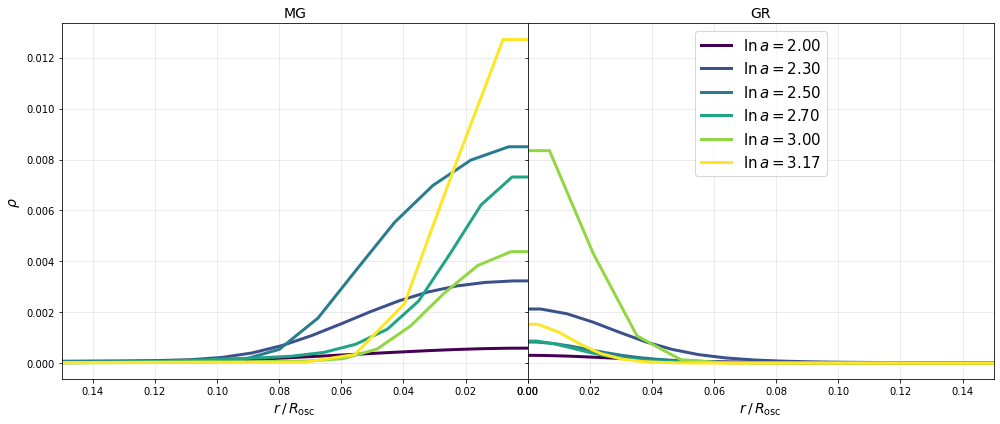

In [17]:
####################################################
# Mirror plot: MG (left) ← R_osc → GR (right)
####################################################
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter

lna_values = [2.0, 2.3, 2.5, 2.7, 3.0, 3.2]
x_max = 0.15  # in units of R_osc

for key, entry in all_diagnostics.items():
    osc = entry['osc']
    lbl = entry['label']

    fig, (ax_mg, ax_gr) = plt.subplots(
        1, 2, figsize=(14, 6), sharey=True,
        gridspec_kw={'wspace': 0})
    cmap = cm.viridis
    norm = plt.Normalize(vmin=lna_values[0], vmax=lna_values[-1])

    # --- MG panel (left, mirrored) ---
    r_mg    = osc['r']
    ln_a_mg = osc['ln_a']
    rho_mg  = osc['rho']
    R_mg    = osc['R']
    idx_mg  = [np.argmin(np.abs(ln_a_mg - v)) for v in lna_values]

    for val, idx in zip(lna_values, idx_mg):
        R_osc = R_mg[idx] if R_mg[idx] > 0 else 1.0
        color = cmap(norm(val))
        ax_mg.plot(r_mg / R_osc, rho_mg[idx], color=color, lw=3,
                   label=rf'$\ln a = {ln_a_mg[idx]:.2f}$')

    ax_mg.set_xlim(0, x_max)
    ax_mg.invert_xaxis()
    ax_mg.set_ylabel(r'$\rho$', fontsize=14)
    ax_mg.set_title('MG', fontsize=14)
    #ax_mg.legend(fontsize=9, loc='upper left')
    ax_mg.grid(True, alpha=0.3)
    ax_mg.set_xlabel(r'$r\,/\,R_{\rm osc}$', fontsize=14)

    # --- GR panel (right, normal) ---
    r_gr    = osc_HR['r']
    ln_a_gr = osc_HR['ln_a']
    
    ln_a_gr = np.array(ln_a_gr)- 0.307
    
    rho_gr  = osc_HR['rho']
    R_gr    = osc_HR['R']
    idx_gr  = [np.argmin(np.abs(ln_a_gr - v)) for v in lna_values]
    
    
    for val, idx in zip(lna_values, idx_gr):
        R_osc = R_gr[idx] if R_gr[idx] > 0 else 1.0
        color = cmap(norm(val))
        ax_gr.plot(r_gr / R_osc, rho_gr[idx], color=color, lw=3,
                   label=rf'$\ln a = {ln_a_gr[idx]:.2f}$')

    ax_gr.set_xlim(0, x_max)
    ax_gr.set_xlabel(r'$r\,/\,R_{\rm osc}$', fontsize=14)
    ax_gr.set_title('GR', fontsize=14)
    ax_gr.legend(fontsize=15, loc='upper center')
    ax_gr.grid(True, alpha=0.3)
    ax_gr.tick_params(labelleft=False)

    fig.tight_layout()
    plt.show()